In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D


from matplotlib.text import Annotation

class Annotation3D(Annotation):

    def __init__(self, text, xyz, *args, **kwargs):
        super().__init__(text, xy=(0, 0), *args, **kwargs)
        self._xyz = xyz

    def draw(self, renderer):
        x2, y2, z2 = proj_transform(*self._xyz, self.axes.M)
        self.xy = (x2, y2)
        super().draw(renderer)

In [8]:
def _annotate3D(ax, text, xyz, *args, **kwargs):
    '''Add anotation `text` to an `Axes3d` instance.'''

    annotation = Annotation3D(text, xyz, *args, **kwargs)
    ax.add_artist(annotation)

setattr(Axes3D, 'annotate3D', _annotate3D)

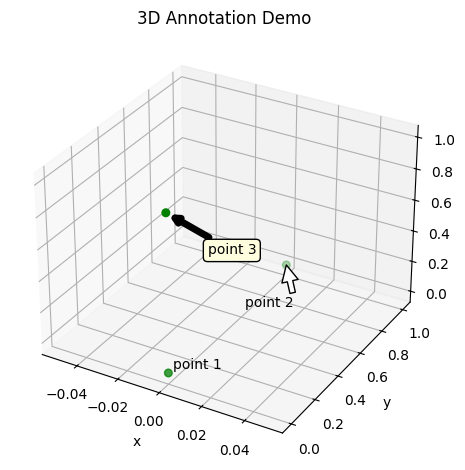

In [9]:


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# adding a few 3d points to annotate
ax.scatter([0, 0, 0], [0, 0, 1], [0, 1, 0], s=30, marker='o', color='green')
ax.annotate3D('point 1', (0, 0, 0), xytext=(3, 3), textcoords='offset points')
ax.annotate3D('point 2', (0, 1, 0),
              xytext=(-30, -30),
              textcoords='offset points',
              arrowprops=dict(ec='black', fc='white', shrink=2.5))
ax.annotate3D('point 3', (0, 0, 1),
              xytext=(30, -30),
              textcoords='offset points',
              bbox=dict(boxstyle="round", fc="lightyellow"),
              arrowprops=dict(arrowstyle="-|>", ec='black', fc='white', lw=5))
ax.set_title('3D Annotation Demo')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig.tight_layout()



     


In [10]:
import numpy as np
from matplotlib.patches import FancyArrowPatch



In [11]:
class Arrow3D(FancyArrowPatch):

    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs) 

In [12]:
def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    '''Add an 3d arrow to an `Axes3D` instance.'''

    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)


setattr(Axes3D, 'arrow3D', _arrow3D)




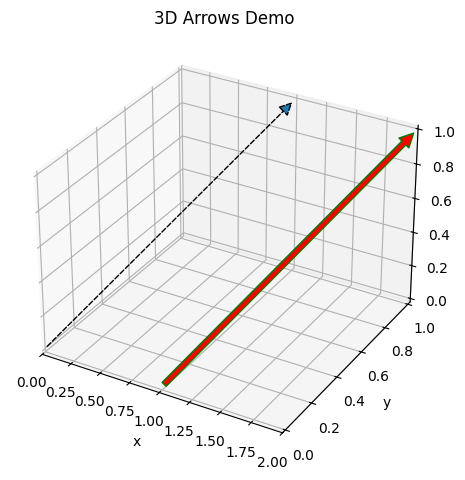

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(0,2)
ax.arrow3D(0,0,0,
           1,1,1,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='dashed')
ax.arrow3D(1,0,0,
           1,1,1,
           mutation_scale=20,
           ec ='green',
           fc='red')
ax.set_title('3D Arrows Demo')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig.tight_layout()

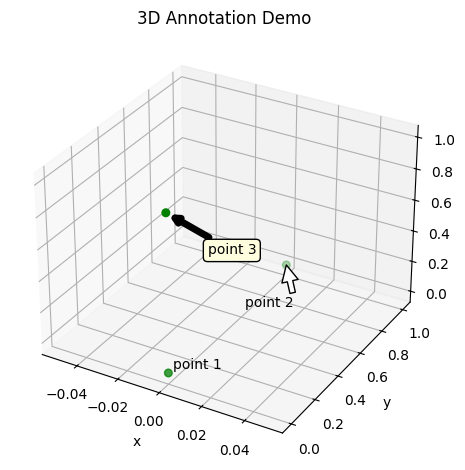

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# adding a few 3d points to annotate
ax.scatter([0, 0, 0], [0, 0, 1], [0, 1, 0], s=30, marker='o', color='green')
ax.annotate3D('point 1', (0, 0, 0), xytext=(3, 3), textcoords='offset points')
ax.annotate3D('point 2', (0, 1, 0),
              xytext=(-30, -30),
              textcoords='offset points',
              arrowprops=dict(ec='black', fc='white', shrink=2.5))
ax.annotate3D('point 3', (0, 0, 1),
              xytext=(30, -30),
              textcoords='offset points',
              bbox=dict(boxstyle="round", fc="lightyellow"),
              arrowprops=dict(arrowstyle="-|>", ec='black', fc='white', lw=5))
ax.set_title('3D Annotation Demo')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig.tight_layout()


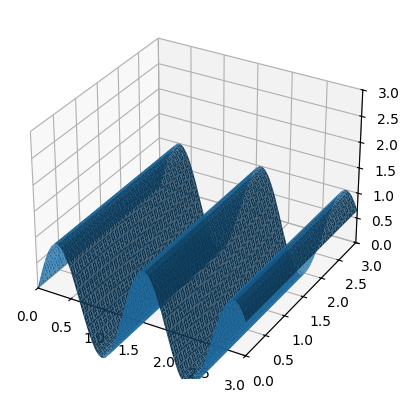

<Figure size 640x480 with 0 Axes>

In [84]:
from mpl_toolkits.mplot3d import axes3d
import math


xTemplate = [0,1,0,1,0,1]
yTemplate = [0,0,1,0,1,1]
zTemplate = [0,0,0,0,0,0]


def getHeight(x, y):
    return math.sin(x * 5)

x = []
y = []
z = []

patches = 64
patchStep =  3 / patches
for patchX in range(0, patches):
    for patchY in range(0, patches):
        for i in range(0,6):
            xCoord = xTemplate[i] * patchStep + patchX * patchStep
            yCoord = yTemplate[i] * patchStep + patchY * patchStep
            x.append(xCoord)
            y.append(yCoord)
            z.append(getHeight(xCoord, yCoord))
    
    





     

ax = plt.figure().add_subplot(111, projection='3d')

ax.set_xlim(0,3)
ax.set_ylim(0,3)
ax.set_zlim(0,3)

ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True)
""""
ax.arrow3D(1,1,2,
           0,0,1,
           mutation_scale=5,
           ec ='red',
           fc='red')
"""

#ax.annotate3D('normal (0,0,1)', (1, 1, 2), xytext=(3, 3), textcoords='offset points')

fig = plt.figure()
fig.tight_layout()
plt.show()